Dataset:

   Area  Bedrooms    Price
0  1000         2  3000000
1  1200         2  3500000
2  1500         3  4500000
3  1800         3  5000000
4  2000         4  6000000
5  2200         4  6500000
6  2500         4  7000000
7  2700         5  7500000
8  3000         5  8500000
9  3500         6  9500000

Missing Values:

Area        0
Bedrooms    0
Price       0
dtype: int64


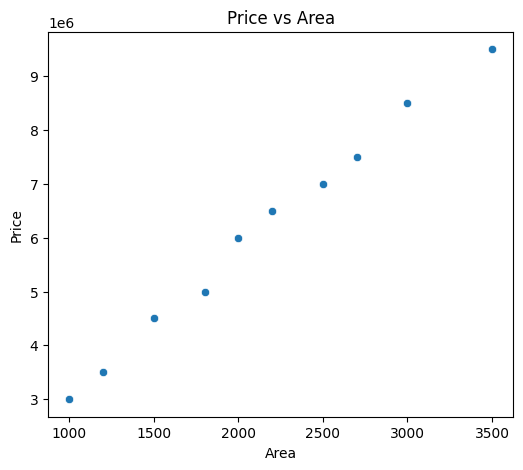

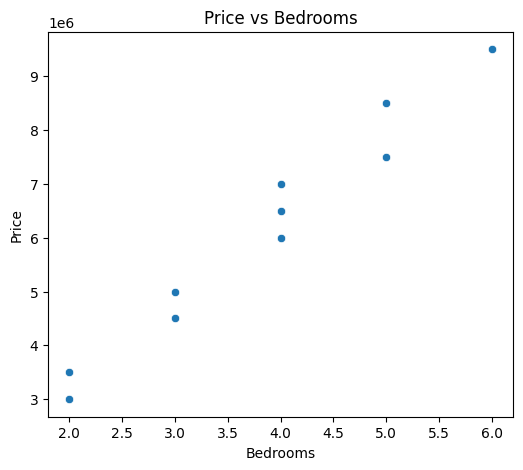


Predicted Prices:

[8237617.9245283  3527122.64150943]

Comparison:

   Actual Price  Predicted Price
8       8500000     8.237618e+06
1       3500000     3.527123e+06

MAE: 144752.35849056672
MSE: 34789995605.642876
R2 Score: 0.9944336007030972


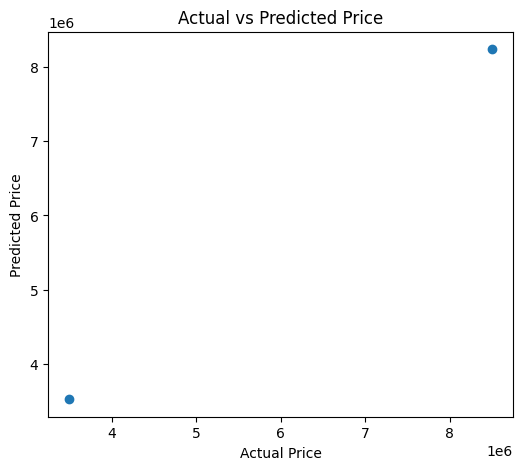


Model Saved Successfully!

Predicted Price for New House:
6667452.830188679

Dataset Exported Successfully!

========== CONCLUSION ==========
1. House price increases with area.
2. More bedrooms increase house price.
3. Linear Regression predicts house prices effectively.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [3]:
# ==========================================
# HOUSE PRICE PREDICTION PROJECT
# Growfinix Internship Task 2
# ==========================================

# STEP 1 - Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

# STEP 2 - Create Dataset

data = {
    "Area": [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2700, 3000, 3500],
    "Bedrooms": [2, 2, 3, 3, 4, 4, 4, 5, 5, 6],
    "Price": [3000000, 3500000, 4500000, 5000000, 6000000,
              6500000, 7000000, 7500000, 8500000, 9500000]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# STEP 3 - Check Missing Values

print("\nMissing Values:\n")
print(df.isnull().sum())

# STEP 4 - Visualize Data

# Price vs Area

plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Area",
    y="Price",
    data=df
)

plt.title("Price vs Area")

plt.savefig("price_vs_area.png")

plt.show()

# Price vs Bedrooms

plt.figure(figsize=(6,5))

sns.scatterplot(
    x="Bedrooms",
    y="Price",
    data=df
)

plt.title("Price vs Bedrooms")

plt.savefig("price_vs_bedrooms.png")

plt.show()

# STEP 5 - Split Dataset

X = df[["Area", "Bedrooms"]]

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# STEP 6 - Train Model

model = LinearRegression()

model.fit(X_train, y_train)

# STEP 7 - Predict

y_pred = model.predict(X_test)

print("\nPredicted Prices:\n")
print(y_pred)

# STEP 8 - Compare Real vs Predicted

comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print("\nComparison:\n")
print(comparison)

# STEP 9 - Accuracy Metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("\nMAE:", mae)

print("MSE:", mse)

print("R2 Score:", r2)

# STEP 10 - Regression Plot

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.savefig("actual_vs_predicted.png")

plt.show()

# STEP 11 - Save Model

joblib.dump(model, "house_price_model.pkl")

print("\nModel Saved Successfully!")

# STEP 12 - Predict New House Price

new_house = [[2400, 4]]

predicted_price = model.predict(new_house)

print("\nPredicted Price for New House:")

print(predicted_price[0])

# STEP 13 - Export Dataset

df.to_csv(
    "house_price_dataset.csv",
    index=False
)

print("\nDataset Exported Successfully!")

# STEP 14 - Conclusion

print("\n========== CONCLUSION ==========")

print("1. House price increases with area.")

print("2. More bedrooms increase house price.")

print("3. Linear Regression predicts house prices effectively.")